# Main

In [13]:
%pip install --upgrade pip setuptools
%pip install pandas

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 4.5 MB/s eta 0:00:01
   ----------- ---------------------------- 0.5/1.8 MB 4.5 MB/s eta 0:00:01
   ----------------------- ---------------- 1.0/1.8 MB 1.4 MB/s eta 0:00:01
   ---------------------------- ----------- 1.3/1.8 MB 1.4 MB/s eta 0:00:01
   ---------------------------------- ----- 1.6/1.8 MB 1.4 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 1.4 MB/s  0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 26.0.1
    Uninstalling pip-26.0.1:
      Successfully uninstalled pip-26.0.1
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


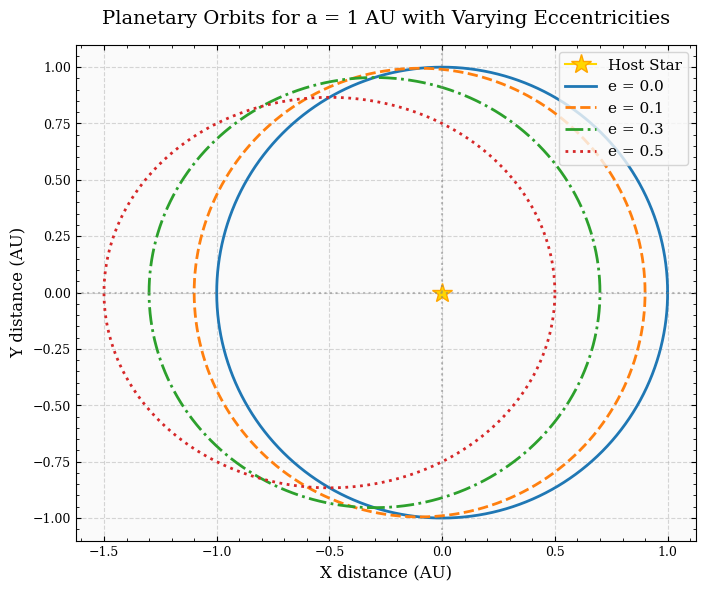

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
a = 1.0  # Semi-major axis in AU
eccentricities = [0.0, 0.1, 0.3, 0.5]
line_styles = ['-', '--', '-.', ':']

# Set up the figure with an equal aspect ratio
fig, ax = plt.subplots(figsize=(8, 8))

# Plot the host star at the focus (0, 0)
ax.plot(0, 0, marker='*', color='gold', markersize=15, markeredgecolor='orange', label='Host Star')

# Generate points for the eccentric anomaly (E) from 0 to 2*pi
E = np.linspace(0, 2 * np.pi, 1000)

# Calculate and plot each orbit
for e, style in zip(eccentricities, line_styles):
    # Parametric equations relative to the focus
    x = a * (np.cos(E) - e)
    y = a * np.sqrt(1 - e**2) * np.sin(E)
    
    ax.plot(x, y, label=f'e = {e}', linestyle=style, linewidth=2)

# Figure Styling
ax.set_title('Planetary Orbits for a = 1 AU with Varying Eccentricities', fontsize=14, pad=15)
ax.set_xlabel('X distance (AU)', fontsize=12)
ax.set_ylabel('Y distance (AU)', fontsize=12)

# Ensure the axes are scaled equally so circles look like circles
ax.set_aspect('equal', 'box')

# Add auxiliary elements
ax.axhline(0, color='grey', linestyle=':', alpha=0.5)
ax.axvline(0, color='grey', linestyle=':', alpha=0.5)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=11, loc='upper right')

# Show the plot
plt.show()

In [3]:

#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Tue Oct 30 10:05:04 2025

@author: jiachenliu
"""

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ---------- your original fixed parameters ----------
N_lat = 400
mu = np.linspace(-1, 1, N_lat)
dmu = mu[1] - mu[0]
S0 = 1361.0  # W/m^2 (Solar constant)
C = 5.25e6
D_corrected = 0.1
Ti = 263
T0 = 273
alpha_warm = 0.3
alpha_cold = 0.6
a = 1.496e11
epsilion = 0.9
sigma= 5.6703e-8
phi_offset = 0.0   # radians; perihelion aligns with vernal equinox
obliquity_rad = np.deg2rad(23.45)

t_span = (0, 365 * 50)
num_steps = 4000
t_eval = np.linspace(*t_span, num_steps)

# Kepler solver and insolation as you had
def solve_kepler(M, e, tol=1e-8):
    E = M
    for _ in range(200):
        delta = (E - e * np.sin(E) - M) / (1 - e * np.cos(E))
        E -= delta
        if abs(delta) < tol:
            break
    return E


def get_albedo_profile(T, Ti=Ti, T0=T0, alpha_warm=alpha_warm, alpha_cold=alpha_cold):
    T = np.asarray(T)
    a = np.empty_like(T)
    low = T <= Ti
    high = T >= T0
    mid = (~low) & (~high)
    a[low] = alpha_cold
    a[high] = alpha_warm
    if np.any(mid):
        # smooth quadratic ramp between T0 and Ti
        a[mid] = alpha_warm + (alpha_cold - alpha_warm) * ((T[mid] - T0)**2) / ((Ti - T0)**2)
    return a


# ---------- New Seasonal Insolation Function (REPLACES BOTH your old ones) ----------

def daily_insolation_profile(t_day, e, obliquity_rad):
    day_of_year = t_day % 365.25
    M = 2 * np.pi * day_of_year / 365.25
    E = solve_kepler(M, e)
    r_over_a = (1 - e * np.cos(E))
    S_t = S0 / (r_over_a**2)   # consistent: S0 at 1 AU scaled by r

    # true anomaly and solar longitude
    true_anomaly = 2 * np.arctan2(np.sqrt(1+e) * np.sin(E/2),
                                  np.sqrt(1-e) * np.cos(E/2))

    solar_longitude = true_anomaly + phi_offset

    # compute declination delta
    sin_delta = np.sin(obliquity_rad) * np.sin(solar_longitude)
    # clamp to [-1,1] and compute delta
    sin_delta = np.clip(sin_delta, -1.0, 1.0)
    delta = np.arcsin(sin_delta)
    cos_delta = np.cos(delta)

    # lat quantities
    mu_clipped = np.clip(mu, -0.9999, 0.9999)
    cos_lat = np.sqrt(1 - mu_clipped**2)
    tan_lat = mu_clipped / cos_lat
    tan_delta = np.tan(delta)
    arg = -tan_lat * tan_delta  #capturing Arctic/Antarctic behavior.
    # handle polar cases: clip arg to [-1,1], arccos returns appropriate h0
    arg_clipped = np.clip(arg, -1.0, 1.0)
    h0 = np.arccos(arg_clipped)

    # daily mean insolation
    S_mu = (S_t / np.pi) * (h0 * mu_clipped * sin_delta + cos_lat * cos_delta * np.sin(h0))
    # numerical safety: set negative to zero
    S_mu = np.maximum(S_mu, 0.0)
    return S_mu

# --------- New conservative finite-volume diffusion operator ----------
def diffusion_operator_fv(T, D):
    """
    Compute divergence of flux: d/dmu[(1-mu^2) D dT/dmu]
    using a finite-volume style discretization on uniform mu-grid.
    Nodes: 0..N-1, Interfaces: 0..N
    flux_interface[0] and flux_interface[N] are at poles -> set to 0 (no flux)
    """
    N = T.size
    # interfaces count = N+1
    flux_if = np.zeros(N + 1)   # flux at interfaces k=0..N

    # mu at interfaces (k from 1..N-1 are interior interfaces)
    # interface k between node k-1 and k: mu_if = 0.5*(mu[k-1] + mu[k])
    mu_if = np.empty(N + 1)
    mu_if[0] = -1.0  # south pole interface
    mu_if[-1] = 1.0  # north pole interface
    mu_if[1:-1] = 0.5 * (mu[:-1] + mu[1:])

    # compute interface-centered gradient (T[k] - T[k-1]) / dmu for k=1..N-1
    # flux_if[k] = (1 - mu_if[k]**2) * D * (T[k] - T[k-1]) / dmu
    # boundaries flux_if[0] and flux_if[N] remain zero (no flux)
    diffT = (T[1:] - T[:-1]) / dmu               # length N-1, corresponds to interfaces 1..N-1
    coeff = (1.0 - mu_if[1:-1]**2) * D          # length N-1
    flux_if[1:-1] = coeff * diffT

    # now divergence at nodes i: (flux_interface[i+1] - flux_interface[i]) / dmu
    div = (flux_if[1:] - flux_if[:-1]) / dmu     # length N

    # two optional stabilizations (uncomment if you still see small-scale wiggles):
    # 1) small explicit hyperdiffusion (4th-order) to remove grid-scale noise:
    # lap = np.zeros_like(T); lap[1:-1] = (T[2:] - 2*T[1:-1] + T[:-2]) / (dmu**2)
    # div += 1e-6 * lap   # tweak coefficient if needed

    return div

# ---------- dTdt using the new insolation AND corrected constants ----------
def dTdt(t, T, e, obliquity_rad, D_coeff):
    S_mu = daily_insolation_profile(t, e, obliquity_rad)   # shape (N_lat,)
    # OLR (Stefan-Boltzmann)
    OLR = epsilion * sigma * T**4
    # diffusion
    d2T_dmu2 = diffusion_operator_fv(T, D_coeff)
    # use temperature-dependent albedo
    albedo_profile = get_albedo_profile(T)
    # net flux
    net_flux = S_mu * (1 - albedo_profile) - OLR + d2T_dmu2
    dT_dt = net_flux / C   # K/s
    return dT_dt * 86400.0  # K/day


# ---------- run_ebm now using BDF and all parameters ----------
def run_ebm(eccentricity, T_init0=288.0):


    T_init = np.full(N_lat, T_init0)
    f_args = (eccentricity, obliquity_rad, D_corrected)

    sol = solve_ivp(dTdt, t_span, T_init, args=f_args,
                    t_eval=t_eval, method='BDF', atol=1e-6, rtol=1e-6)
    return sol.t, sol.y



# Result

In [4]:
eccs = [0, 0.1, 0.3, 0.5]
results = {}

for e in eccs:
    t, T = run_ebm(eccentricity=e)

    # Keep exactly year 50
    start_day = 365 * 49
    mask = t >= start_day

    t_final = t[mask] - start_day     # local time measured from start of year 49
    T_final = T[:, mask]

    results[e] = {
        "t": t_final,   # local time: ~0 to ~730
        "T": T_final
    }

In [14]:
import pandas as pd
import os

lat = np.degrees(np.arcsin(mu))

# Create output directory in Downloads (or change to your preferred path)
output_dir = r"C:\Users\MD TALHA ZOBAIR\Downloads\EBM_results1"
os.makedirs(output_dir, exist_ok=True)

for e, data in results.items():
    T = data["T"]
    t = data["t"]

    df = pd.DataFrame(
        T,
        index=lat,
        columns=np.round(t, 2)
    )
    df.index.name = "latitude_deg"
    df.columns.name = "day"

    filename = os.path.join(output_dir, f"EBM_temperature_e_{e:.2f}.csv")
    df.to_csv(filename)

print(f"Results exported to {output_dir}")

Results exported to C:\Users\MD TALHA ZOBAIR\Downloads\EBM_results1


In [15]:
def area_weighted_mean(T):
    weights = np.cos(np.arcsin(mu))
    return np.sum(T * weights[:, None], axis=0) / np.sum(weights)

summary_rows = []

for e, data in results.items():
    T = data["T"]

    T_mean = area_weighted_mean(T).mean()
    T_eq = T[np.argmin(np.abs(mu)), :].mean()
    T_pole = 0.5 * (T[0, :].mean() + T[-1, :].mean())

    summary_rows.append({
        "eccentricity": e,
        "mean_T_K": T_mean,
        "equator_T_K": T_eq,
        "pole_T_K": T_pole
    })

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv("EBM_climate_summary.csv", index=False)
print("EBM_climate_summary.csv has been saved.")

EBM_climate_summary.csv has been saved.


# Plotting

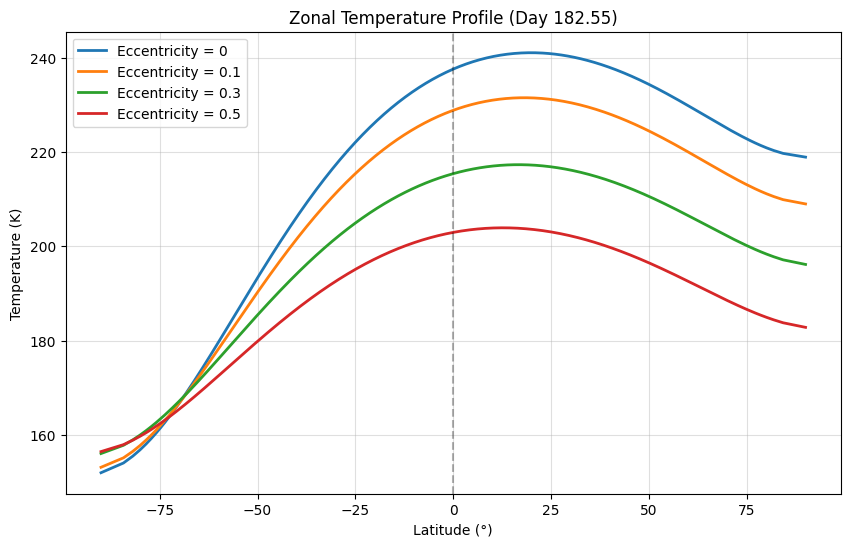

In [4]:
def plot_temp_vs_lat(results, mu, snapshot_day):  # Added mu as an argument
    plt.figure(figsize=(10, 6))

    # Convert sine-latitude to degrees
    lat = np.degrees(np.arcsin(mu))

    for e, data in results.items():
        t = data["t"]
        T = data["T"]

        # Find the index closest to the desired day
        idx = np.argmin(np.abs(t - snapshot_day))
        T_lat = T[:, idx]

        plt.plot(lat, T_lat, label=f"Eccentricity = {e}", linewidth=2)

    # Aesthetics
    plt.axvline(0, color='black', linestyle='--', alpha=0.3) # Equator marker
    plt.xlabel("Latitude (°)")
    plt.ylabel("Temperature (K)")
    plt.title(f"Zonal Temperature Profile (Day {snapshot_day})")
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.show()

# Call it like this:
plot_temp_vs_lat(results, mu, snapshot_day=182.55)  # Plot for day 180 (mid-year)


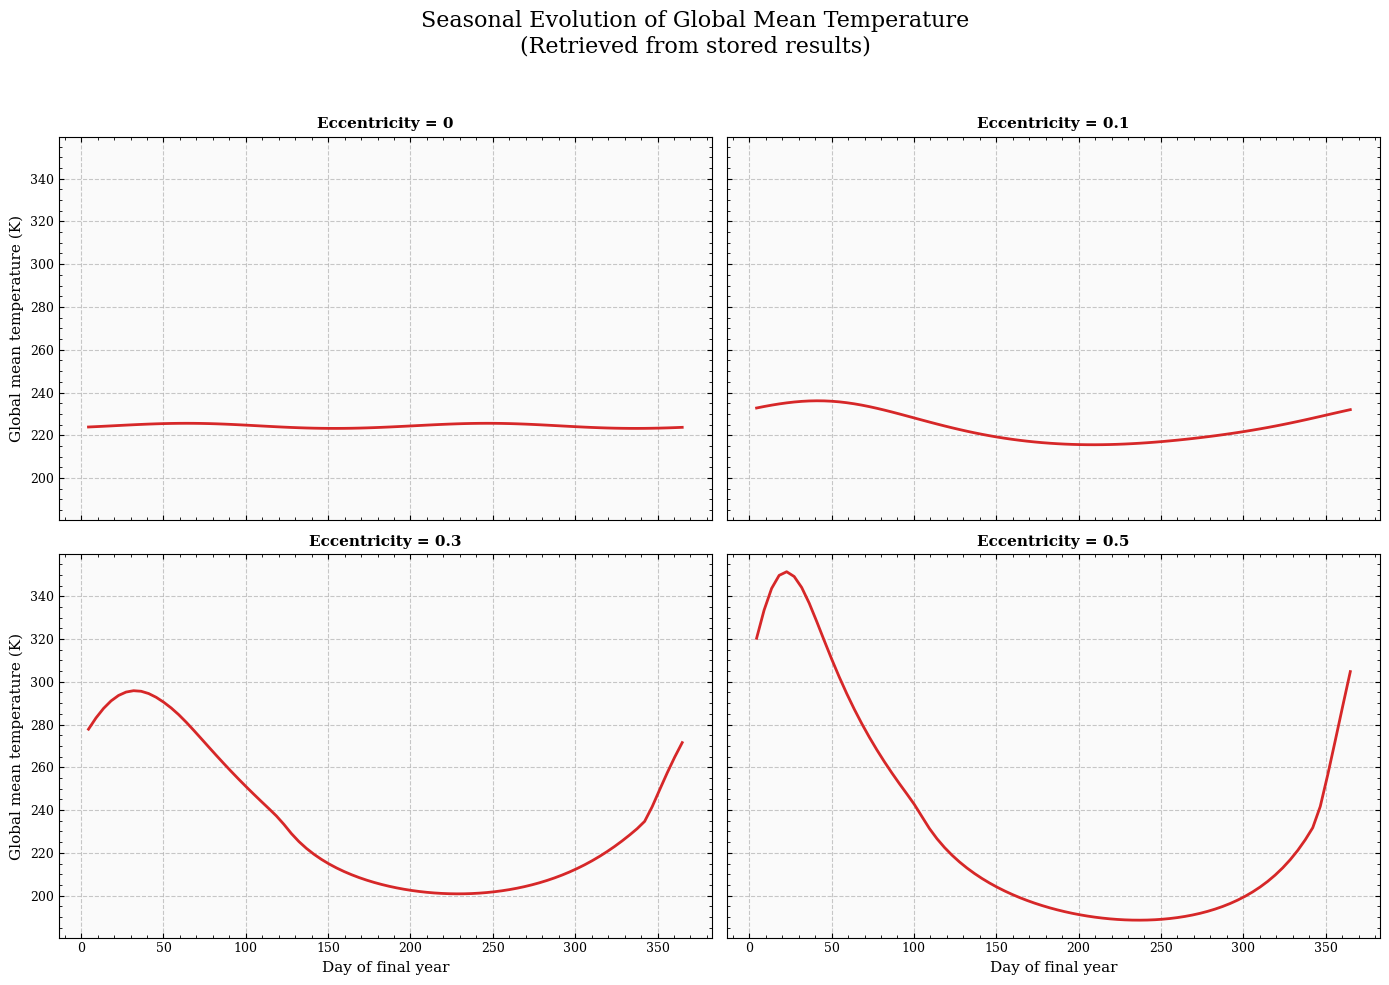

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup the figure (2x2 grid)
fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axs = axs.flatten()

# 2. Iterate through your stored results
# Using 'enumerate' helps us place each eccentricity in the correct subplot (0-3)
for i, e in enumerate([0, 0.1, 0.3, 0.5]):
    # Pull the pre-calculated data from your dictionary
    t_final = results[e]["t"]
    T_final = results[e]["T"]

    # 3. Calculate Global Mean Temperature
    # T_final has shape (N_lat, N_time).
    # np.trapezoid integrates over the latitude (mu) dimension (axis 0).
    # We divide by 2.0 because the integral of mu from -1 to 1 is 2.
    T_mean = np.trapezoid(T_final, mu, axis=0) / 2.0

    # 4. Plotting
    axs[i].plot(t_final, T_mean, linewidth=2, color='tab:red')

    # Formatting each subplot
    axs[i].set_title(f"Eccentricity = {e}", fontweight='bold')
    axs[i].grid(True, linestyle='--', alpha=0.7)

    # Label only the bottom row and left column for a cleaner look
    if i >= 2:
        axs[i].set_xlabel("Day of final year")
    if i % 2 == 0:
        axs[i].set_ylabel("Global mean temperature (K)")

# 5. Global formatting
plt.suptitle(
    "Seasonal Evolution of Global Mean Temperature\n(Retrieved from stored results)",
    fontsize=16,
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

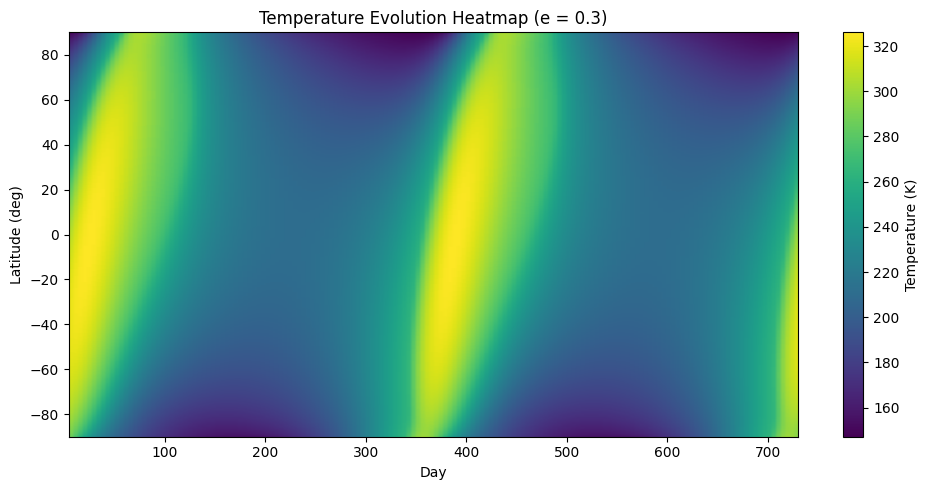

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Choose eccentricity to display
e_plot = 0.3
data = results[e_plot]

T = data["T"]           # shape: (lat, time)
t = data["t"]           # time array
lat = np.degrees(np.arcsin(mu))

plt.figure(figsize=(10, 5))

plt.imshow(
    T,
    aspect='auto',
    origin='lower',
    extent=[t.min(), t.max(), lat.min(), lat.max()]
)

cbar = plt.colorbar()
cbar.set_label("Temperature (K)")

plt.xlabel("Day")
plt.ylabel("Latitude (deg)")
plt.title(f"Temperature Evolution Heatmap (e = {e_plot})")

plt.tight_layout()
plt.show()

NameError: name 'eccs_sorted' is not defined

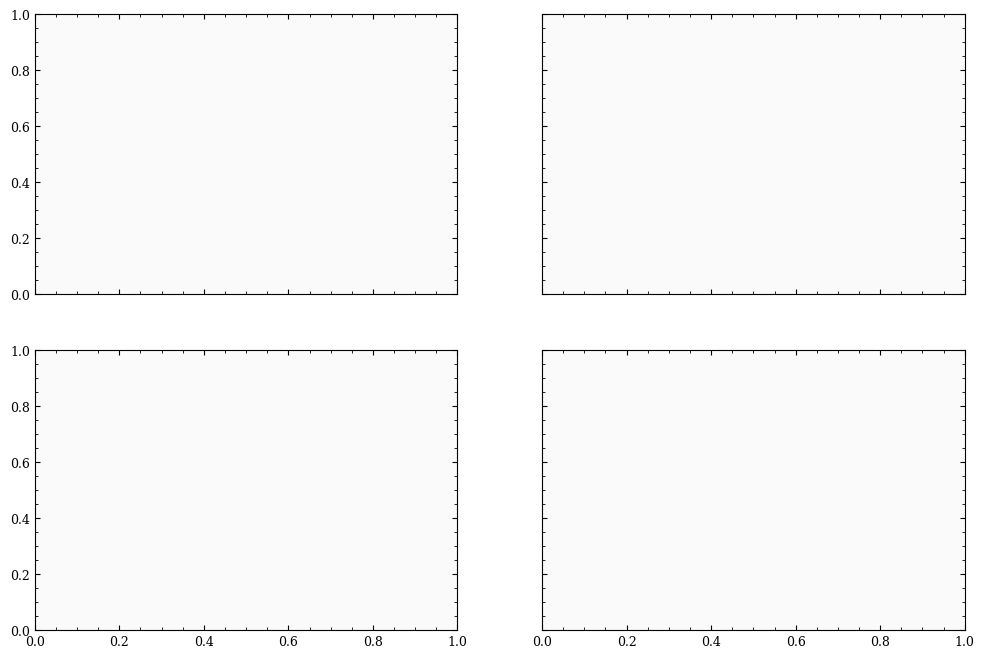

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, e in enumerate(eccs_sorted):
    ax = axes[i]
    data = results[e]
    T = data["T"]
    t = data["t"]

    im = ax.imshow(
        T,
        aspect='auto',
        origin='lower',
        extent=[t.min(), t.max(), lat.min(), lat.max()],
        vmin=vmin,
        vmax=vmax,
        cmap='viridis'
    )

    ax.set_title(f"e = {e}")

    # Only label bottom row x-axis
    if i >= 2:
        ax.set_xlabel("Day")

    # Only label left column y-axis
    if i % 2 == 0:
        ax.set_ylabel("Latitude (deg)")

# Use plt.subplots_adjust to reserve space at the bottom BEFORE adding colorbar
plt.subplots_adjust(bottom=0.15, hspace=0.3, wspace=0.05)

# Add colorbar in a dedicated axes at the bottom
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Temperature (K)")

plt.suptitle("Latitude-Time Temperature Evolution Across Eccentricities", fontsize=14, y=1.01)
# Do NOT call plt.tight_layout() — it conflicts with manual subplots_adjust
plt.show()

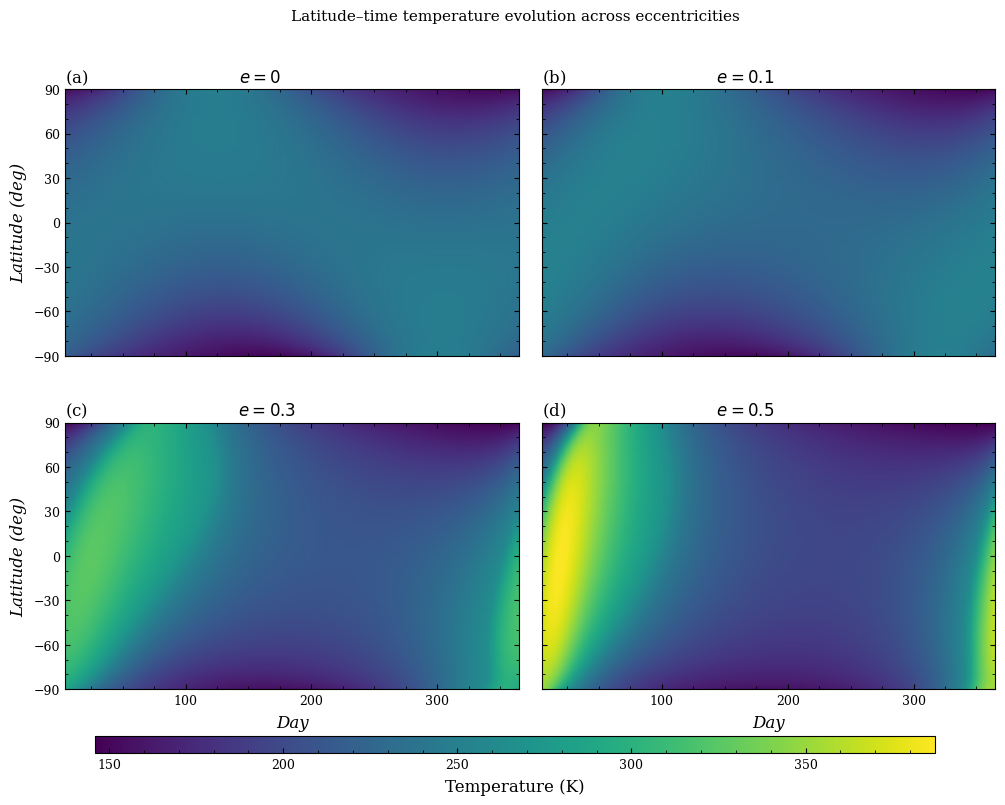

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import os

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
})

data_dir = r"C:\Users\MD TALHA ZOBAIR\Downloads\EBM_results1"
eccs = [0, 0.1, 0.3, 0.5]

all_T, lat_ref, t_ref = [], None, None
for e in eccs:
    df = pd.read_csv(os.path.join(data_dir, f"EBM_temperature_e_{e:.2f}.csv"), index_col=0)
    all_T.append(df.values)
    if lat_ref is None:
        lat_ref = df.index.values.astype(float)
        t_ref   = df.columns.values.astype(float)

vmin = np.min([T.min() for T in all_T])
vmax = np.max([T.max() for T in all_T])

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

panel_tags = ["(a)", "(b)", "(c)", "(d)"]

for i, (e, T) in enumerate(zip(eccs, all_T)):
    ax = axes[i]

    im = ax.imshow(
        T,
        aspect="auto",
        origin="lower",
        extent=[t_ref.min(), t_ref.max(), lat_ref.min(), lat_ref.max()],
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        interpolation="bilinear",
    )
    ax.set_title(f"{panel_tags[i]}$\\ \\ \\ \\ \\ \\ \\ \\ \\ \\ \\ \\ \\ \\ \\ \\ \\ \\ \\ \\ \\ \\ \\qquad e = {e}$", pad=5, loc="left")

    ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(25))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(30))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(10))

    if i >= 2:
        ax.set_xlabel("Day", labelpad=5, fontstyle="italic")
    if i % 2 == 0:
        ax.set_ylabel("Latitude (deg)", labelpad=5, fontstyle="italic")

plt.subplots_adjust(bottom=0.13, hspace=0.25, wspace=0.05)
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.022])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Temperature (K)", labelpad=5)
cbar.ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
cbar.ax.xaxis.set_minor_locator(ticker.MultipleLocator(10))
cbar.ax.tick_params(direction="in", which="both")

fig.suptitle("Latitude–time temperature evolution across eccentricities",
             fontsize=11, fontweight="normal", y=0.98)

plt.savefig("EBM_heatmap_viridis.pdf", bbox_inches="tight")
plt.savefig("EBM_heatmap_viridis.png", dpi=300, bbox_inches="tight")
plt.show()

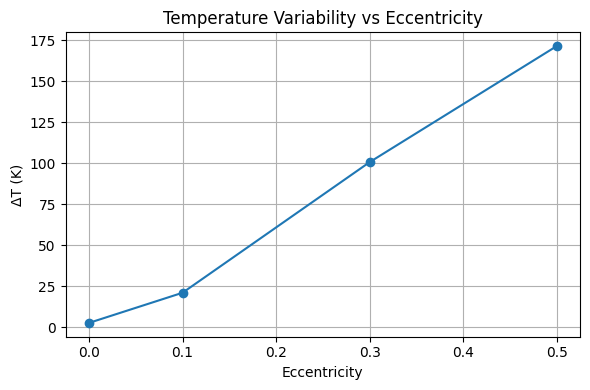

In [8]:
import numpy as np
import matplotlib.pyplot as plt

eccs_sorted = sorted(results.keys())
delta_T = []

for e in eccs_sorted:
    T = results[e]["T"]

    # Global mean temperature
    weights = np.cos(np.arcsin(mu))
    T_global = np.sum(T * weights[:, None], axis=0) / np.sum(weights)

    dT = T_global.max() - T_global.min()
    delta_T.append(dT)

plt.figure(figsize=(6, 4))

plt.plot(eccs_sorted, delta_T, marker='o')

plt.xlabel("Eccentricity")
plt.ylabel("ΔT (K)")
plt.title("Temperature Variability vs Eccentricity")

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import os

data_dir = r"C:\Users\MD TALHA ZOBAIR\Downloads\EBM_results1"
lat = np.degrees(np.arcsin(mu))
eccs = [0, 0.1, 0.3, 0.5]   # change 0.0 to 0

for color, e in zip(colors, eccs):
    col = f"e={e}"            # now gives "e=0", "e=0.1" etc. — matches CSV
    ax.plot(t, df[col].values, linewidth=1.8, color=color, label=f"$e = {e}$")
result = {}
for e, data in results.items():
    T       = data["T"]
    t       = data["t"]
    weights = np.cos(np.deg2rad(lat))
    T_mean  = np.sum(T * weights[:, None], axis=0) / np.sum(weights)
    result[f"e={e}"] = T_mean

out = pd.DataFrame(result, index=t)
out.index.name = "Day"
out.to_csv(os.path.join(data_dir, "EBM_global_mean_C_525_1yr.csv"))
print("Saved.")

Saved.


Saved.


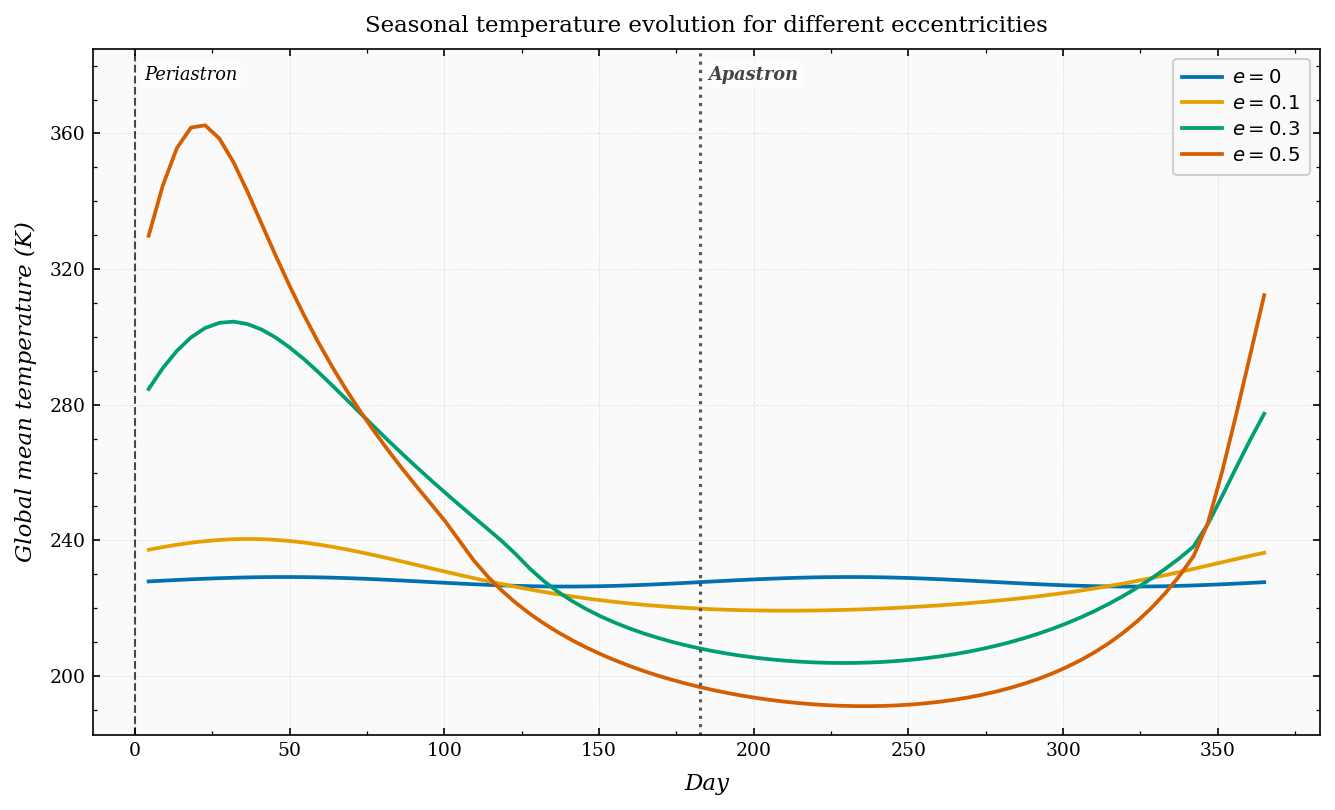

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import os

# --- Save ---
data_dir = r"C:\Users\MD TALHA ZOBAIR\Downloads\EBM_results1"
lat      = np.degrees(np.arcsin(mu))

result = {}
for e, data in results.items():
    T       = data["T"]
    t_arr   = data["t"]
    weights = np.cos(np.deg2rad(lat))
    T_mean  = np.sum(T * weights[:, None], axis=0) / np.sum(weights)
    result[f"e={e}"] = T_mean

out = pd.DataFrame(result, index=t_arr)
out.index.name = "Day"
out.to_csv(os.path.join(data_dir, "EBM_global_mean_C_525_1yr.csv"))
print("Saved.")

# --- Plot ---
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "axes.facecolor": "#FAFAFA",
    "figure.facecolor": "white",
})

df = pd.read_csv(
    os.path.join(data_dir, "EBM_global_mean_C_525_1yr.csv"),
    index_col=0)

t      = df.index.values.astype(float)
colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00"]
eccs   = [0, 0.1, 0.3, 0.5]

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=150)

for color, e in zip(colors, eccs):
    col = f"e={e}"
    ax.plot(t, df[col].values, linewidth=1.8, color=color, label=f"$e = {e}$")

ymax = 380

# Periastron at day 0
ax.axvline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.7, zorder=2)
ax.text(3, ymax, "Periastron", ha="left", va="top",
        fontsize=8.5, color="black", fontstyle="italic",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8))

# Apastron at day 182.5
ax.axvline(182.5, color="#444444", linewidth=1.5, linestyle=":", alpha=0.9, zorder=2)
ax.text(185.5, ymax, "Apastron", ha="left", va="top",
        fontsize=8.5, color="#444444", fontweight="bold", fontstyle="italic",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8))

# --- Axes ---
ax.set_ylim(top=ymax + 5)
ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(25))
ax.yaxis.set_major_locator(ticker.MultipleLocator(40))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(10))
ax.grid(True, which="major", linestyle="--", linewidth=0.4, alpha=0.3)

ax.set_xlabel("Day", labelpad=6, fontstyle="italic")
ax.set_ylabel("Global mean temperature (K)", labelpad=6, fontstyle="italic")
ax.set_title("Seasonal temperature evolution for different eccentricities",
             pad=8, fontweight="normal")

ax.legend(loc="upper right", frameon=True, framealpha=0.92,
          edgecolor="#CCCCCC", fontsize=9.5,
          handlelength=2.0, handletextpad=0.5,
          borderpad=0.5, labelspacing=0.35)

plt.tight_layout()
plt.savefig(os.path.join(data_dir, "EBM_temp_peri_aph_1yr.pdf"), bbox_inches="tight")
plt.savefig(os.path.join(data_dir, "EBM_temp_peri_aph_1yr.png"), dpi=300, bbox_inches="tight")
plt.show()

In [1]:
import numpy as np
import pandas as pd
import os

data_dir = r"C:\Users\MD TALHA ZOBAIR\Downloads\EBM_results"
eccs = [0.00, 0.10, 0.30, 0.50]

result = {}

for e in eccs:
    df = pd.read_csv(os.path.join(data_dir, f"EBM_temperature_e_{e:.2f}.csv"), index_col=0)
    
    lat     = df.index.values.astype(float)
    t       = df.columns.values.astype(float)
    T       = df.values
    weights = np.cos(np.deg2rad(lat))
    T_mean  = np.sum(T * weights[:, None], axis=0) / np.sum(weights)
    
    result[f"e={e}"] = T_mean

# Build output dataframe: rows = days, columns = eccentricities
out = pd.DataFrame(result, index=t)
out.index.name = "Day"

out.to_csv(os.path.join(data_dir, "EBM_global_mean_temperature.csv"))
print(out.head())
print(f"\nSaved to: {data_dir}\\EBM_global_mean_temperature.csv")

            e=0.0       e=0.1       e=0.3       e=0.5
Day                                                  
4.38   227.911101  237.266123  284.881103  330.402085
8.94   228.127363  238.046332  290.991371  345.101996
13.51  228.335232  238.738225  296.065657  356.012503
18.07  228.529780  239.326548  299.990277  361.842037
22.64  228.706627  239.798365  302.697980  362.334578

Saved to: C:\Users\MD TALHA ZOBAIR\Downloads\EBM_results\EBM_global_mean_temperature.csv


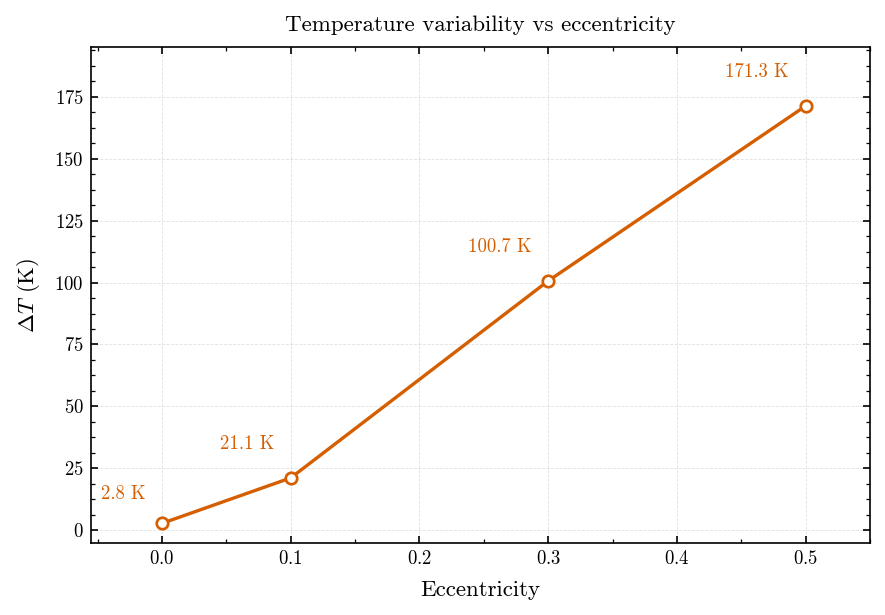

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import os

plt.rcParams.update({
    "text.usetex": False,          # no LaTeX install required
    "mathtext.fontset": "cm",      # Computer Modern look-alike for math text
    "font.family": "serif",
    "font.serif": ["cmr10", "DejaVu Serif"],
    "axes.formatter.use_mathtext": True,
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
})

data_dir = r"C:\Users\MD TALHA ZOBAIR\Downloads\EBM_results1"
eccs = [0.00, 0.10, 0.30, 0.50]

delta_T = []
for e in eccs:
    df      = pd.read_csv(os.path.join(data_dir, f"EBM_temperature_e_{e:.2f}.csv"), index_col=0)
    lat     = df.index.values.astype(float)
    T       = df.values
    weights = np.cos(np.deg2rad(lat))
    T_mean  = np.sum(T * weights[:, None], axis=0) / np.sum(weights)
    delta_T.append(T_mean.max() - T_mean.min())

fig, ax = plt.subplots(figsize=(6.0, 4.2), dpi=150)

ax.plot(eccs, delta_T,
        color="#D55E00",
        linewidth=1.6,
        marker="o",
        markersize=5.5,
        markerfacecolor="white",
        markeredgecolor="#D55E00",
        markeredgewidth=1.3,
        zorder=3)

# Labels above-left of each point, clear of the line
offsets = [(-8, 10), (-8, 12), (-8, 12), (-8, 12)]
for e, dT, (dx, dy) in zip(eccs, delta_T, offsets):
    ax.annotate(f"{dT:.1f} K",
                xy=(e, dT),
                xytext=(dx, dy),
                textcoords="offset points",
                ha="right", va="bottom", fontsize=9,
                color="#D55E00")

ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.05))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(4))
ax.grid(True, which="major", linestyle="--", linewidth=0.4, alpha=0.4, color="0.7")

ax.set_xlabel("Eccentricity", labelpad=6)
ax.set_ylabel(r"$\Delta T$ (K)", labelpad=6)
ax.set_title("Temperature variability vs eccentricity", pad=8, fontweight="normal")

ax.set_xlim(-0.055, 0.55)
ax.set_ylim(-5, 195)

plt.tight_layout()
plt.savefig("EBM_deltaT_vs_e.pdf", bbox_inches="tight")
plt.savefig("EBM_deltaT_vs_e.png", dpi=300, bbox_inches="tight")
plt.show()

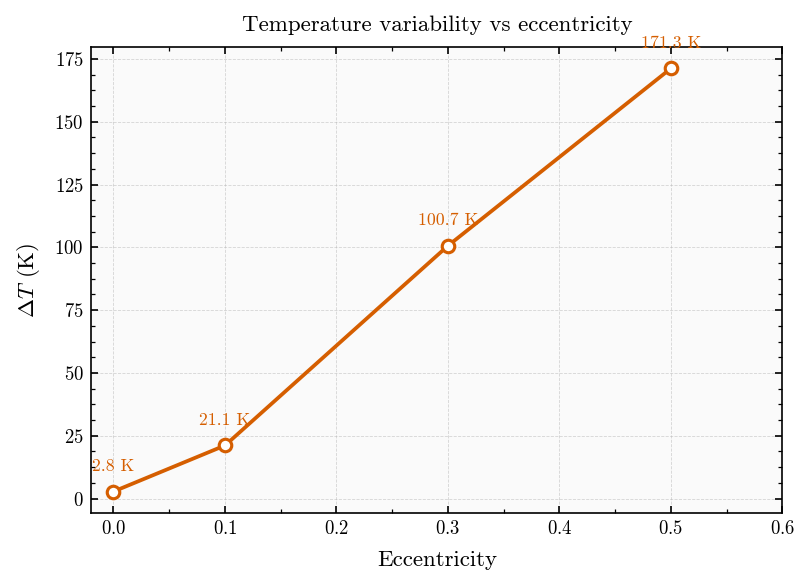

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import os

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "axes.facecolor": "#FAFAFA",
    "figure.facecolor": "white",
})

data_dir = r"C:\Users\MD TALHA ZOBAIR\Downloads\EBM_results1"
eccs = [0.00, 0.10, 0.30, 0.50]

delta_T = []

for e in eccs:
    df      = pd.read_csv(os.path.join(data_dir, f"EBM_temperature_e_{e:.2f}.csv"), index_col=0)
    lat     = df.index.values.astype(float)
    T       = df.values
    weights = np.cos(np.deg2rad(lat))
    T_mean  = np.sum(T * weights[:, None], axis=0) / np.sum(weights)

    delta_T.append(T_mean.max() - T_mean.min())

fig, ax = plt.subplots(figsize=(5.5, 4.0), dpi=150)

ax.plot(eccs, delta_T,
        color="#D55E00",
        linewidth=1.8,
        marker="o",
        markersize=6,
        markerfacecolor="white",
        markeredgecolor="#D55E00",
        markeredgewidth=1.5)

# Annotate each point with its value
for e, dT in zip(eccs, delta_T):
    ax.annotate(f"{dT:.1f} K",
                xy=(e, dT),
                xytext=(0, 10),
                textcoords="offset points",
                ha="center", fontsize=8.5,
                color="#D55E00")

ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.05))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(4))
ax.grid(True, which="major", linestyle="--", linewidth=0.4, alpha=0.5)

ax.set_xlabel("Eccentricity", labelpad=6, fontstyle="italic")
ax.set_ylabel(r"$\Delta T$ (K)", labelpad=6)
ax.set_title("Temperature variability vs eccentricity", pad=8, fontweight="normal")

ax.set_xlim(-0.02, 0.60)

plt.tight_layout()
plt.savefig("EBM_deltaT_vs_e.pdf", bbox_inches="tight")
plt.savefig("EBM_deltaT_vs_e.png", dpi=300, bbox_inches="tight")
plt.show()

# For heat capacity, C =4e6 J/m^2/K

In [37]:

#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Tue Oct 30 10:05:04 2025

@author: jiachenliu
"""

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ---------- your original fixed parameters ----------
N_lat = 400
mu = np.linspace(-1, 1, N_lat)
dmu = mu[1] - mu[0]
S0 = 1361.0  # W/m^2 (Solar constant)
C =  4e6
D_corrected = 0.1
Ti = 263
T0 = 273
alpha_warm = 0.3
alpha_cold = 0.6
a = 1.496e11
epsilion = 0.9
sigma= 5.6703e-8
phi_offset = 0.0   # radians; perihelion aligns with vernal equinox
obliquity_rad = np.deg2rad(23.45)

t_span = (0, 365 * 50)
num_steps = 4000
t_eval = np.linspace(*t_span, num_steps)

# Kepler solver and insolation as you had
def solve_kepler(M, e, tol=1e-8):
    E = M
    for _ in range(200):
        delta = (E - e * np.sin(E) - M) / (1 - e * np.cos(E))
        E -= delta
        if abs(delta) < tol:
            break
    return E


def get_albedo_profile(T, Ti=Ti, T0=T0, alpha_warm=alpha_warm, alpha_cold=alpha_cold):
    T = np.asarray(T)
    a = np.empty_like(T)
    low = T <= Ti
    high = T >= T0
    mid = (~low) & (~high)
    a[low] = alpha_cold
    a[high] = alpha_warm
    if np.any(mid):
        # smooth quadratic ramp between T0 and Ti
        a[mid] = alpha_warm + (alpha_cold - alpha_warm) * ((T[mid] - T0)**2) / ((Ti - T0)**2)
    return a


# ---------- New Seasonal Insolation Function (REPLACES BOTH your old ones) ----------

def daily_insolation_profile(t_day, e, obliquity_rad):
    day_of_year = t_day % 365.25
    M = 2 * np.pi * day_of_year / 365.25
    E = solve_kepler(M, e)
    r_over_a = (1 - e * np.cos(E))
    S_t = S0 / (r_over_a**2)   # consistent: S0 at 1 AU scaled by r

    # true anomaly and solar longitude
    true_anomaly = 2 * np.arctan2(np.sqrt(1+e) * np.sin(E/2),
                                  np.sqrt(1-e) * np.cos(E/2))

    solar_longitude = true_anomaly + phi_offset

    # compute declination delta
    sin_delta = np.sin(obliquity_rad) * np.sin(solar_longitude)
    # clamp to [-1,1] and compute delta
    sin_delta = np.clip(sin_delta, -1.0, 1.0)
    delta = np.arcsin(sin_delta)
    cos_delta = np.cos(delta)

    # lat quantities
    mu_clipped = np.clip(mu, -0.9999, 0.9999)
    cos_lat = np.sqrt(1 - mu_clipped**2)
    tan_lat = mu_clipped / cos_lat
    tan_delta = np.tan(delta)
    arg = -tan_lat * tan_delta  #capturing Arctic/Antarctic behavior.
    # handle polar cases: clip arg to [-1,1], arccos returns appropriate h0
    arg_clipped = np.clip(arg, -1.0, 1.0)
    h0 = np.arccos(arg_clipped)

    # daily mean insolation
    S_mu = (S_t / np.pi) * (h0 * mu_clipped * sin_delta + cos_lat * cos_delta * np.sin(h0))
    # numerical safety: set negative to zero
    S_mu = np.maximum(S_mu, 0.0)
    return S_mu

# --------- New conservative finite-volume diffusion operator ----------
def diffusion_operator_fv(T, D):
    """
    Compute divergence of flux: d/dmu[(1-mu^2) D dT/dmu]
    using a finite-volume style discretization on uniform mu-grid.
    Nodes: 0..N-1, Interfaces: 0..N
    flux_interface[0] and flux_interface[N] are at poles -> set to 0 (no flux)
    """
    N = T.size
    # interfaces count = N+1
    flux_if = np.zeros(N + 1)   # flux at interfaces k=0..N

    # mu at interfaces (k from 1..N-1 are interior interfaces)
    # interface k between node k-1 and k: mu_if = 0.5*(mu[k-1] + mu[k])
    mu_if = np.empty(N + 1)
    mu_if[0] = -1.0  # south pole interface
    mu_if[-1] = 1.0  # north pole interface
    mu_if[1:-1] = 0.5 * (mu[:-1] + mu[1:])

    # compute interface-centered gradient (T[k] - T[k-1]) / dmu for k=1..N-1
    # flux_if[k] = (1 - mu_if[k]**2) * D * (T[k] - T[k-1]) / dmu
    # boundaries flux_if[0] and flux_if[N] remain zero (no flux)
    diffT = (T[1:] - T[:-1]) / dmu               # length N-1, corresponds to interfaces 1..N-1
    coeff = (1.0 - mu_if[1:-1]**2) * D          # length N-1
    flux_if[1:-1] = coeff * diffT

    # now divergence at nodes i: (flux_interface[i+1] - flux_interface[i]) / dmu
    div = (flux_if[1:] - flux_if[:-1]) / dmu     # length N

    # two optional stabilizations (uncomment if you still see small-scale wiggles):
    # 1) small explicit hyperdiffusion (4th-order) to remove grid-scale noise:
    # lap = np.zeros_like(T); lap[1:-1] = (T[2:] - 2*T[1:-1] + T[:-2]) / (dmu**2)
    # div += 1e-6 * lap   # tweak coefficient if needed

    return div

# ---------- dTdt using the new insolation AND corrected constants ----------
def dTdt(t, T, e, obliquity_rad, D_coeff):
    S_mu = daily_insolation_profile(t, e, obliquity_rad)   # shape (N_lat,)
    # OLR (Stefan-Boltzmann)
    OLR = epsilion * sigma * T**4
    # diffusion
    d2T_dmu2 = diffusion_operator_fv(T, D_coeff)
    # use temperature-dependent albedo
    albedo_profile = get_albedo_profile(T)
    # net flux
    net_flux = S_mu * (1 - albedo_profile) - OLR + d2T_dmu2
    dT_dt = net_flux / C   # K/s
    return dT_dt * 86400.0  # K/day


# ---------- run_ebm now using BDF and all parameters ----------
def run_ebm(eccentricity, T_init0=288.0):


    T_init = np.full(N_lat, T_init0)
    f_args = (eccentricity, obliquity_rad, D_corrected)

    sol = solve_ivp(dTdt, t_span, T_init, args=f_args,
                    t_eval=t_eval, method='BDF', atol=1e-6, rtol=1e-6)
    return sol.t, sol.y



In [38]:
eccs = [0, 0.1, 0.3, 0.5]
results = {}

for e in eccs:
    t, T = run_ebm(eccentricity=e)

    # Keep exactly year 50
    start_day = 365 * 49
    mask = t >= start_day

    t_final = t[mask] - start_day     # local time measured from start of year 49
    T_final = T[:, mask]

    results[e] = {
        "t": t_final,   # local time: ~0 to ~730
        "T": T_final
    }

In [43]:
import pandas as pd
import numpy as np
import os

output_dir = r"C:\Users\MD TALHA ZOBAIR\Downloads\EBM_results3"
os.makedirs(output_dir, exist_ok=True)

lat = np.degrees(np.arcsin(mu))

for e, data in results.items():
    df = pd.DataFrame(data["T"], index=lat, columns=np.round(data["t"], 2))
    df.index.name = "latitude_deg"
    df.columns.name = "day"
    df.to_csv(os.path.join(output_dir, f"EBM_temperature_C_4e6_e_{e:.2f}.csv"))
result = {}
for e, data in results.items():
    T       = data["T"]
    t       = data["t"]
    weights = np.cos(np.deg2rad(lat))
    T_mean  = np.sum(T * weights[:, None], axis=0) / np.sum(weights)
    result[f"e={e}"] = T_mean

out = pd.DataFrame(result, index=t)
out.index.name = "Day"
out.to_csv(os.path.join(output_dir, "EBM_global_mean_C_4e6.csv"))
print("Global mean saved.")
print("Done.")

Global mean saved.
Done.


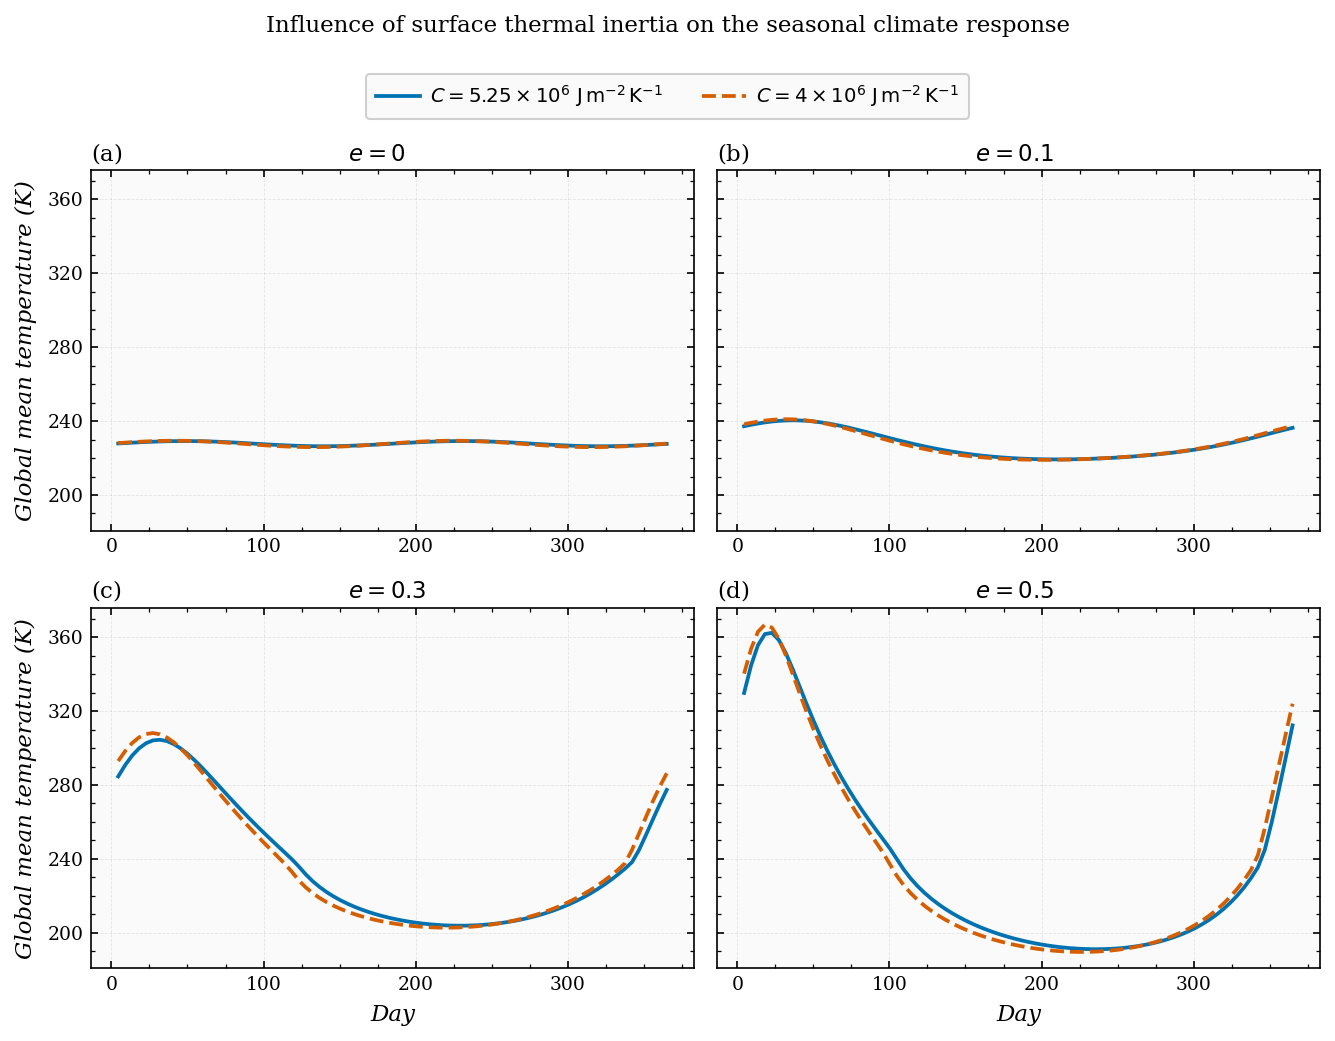

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "axes.facecolor": "#FAFAFA",
    "figure.facecolor": "white",
})

df_C525 = pd.read_csv(
    r"C:\Users\MD TALHA ZOBAIR\Downloads\EBM_results1\EBM_global_mean_C_525_1yr.csv",
    index_col=0)

df_C4 = pd.read_csv(
    r"C:\Users\MD TALHA ZOBAIR\Downloads\EBM_results3\EBM_global_mean_C_4e6.csv",
    index_col=0)

t_C525 = df_C525.index.values.astype(float)
t_C4   = df_C4.index.values.astype(float)

eccs = [0, 0.1, 0.3, 0.5]
panel_tags  = ["(a)", "(b)", "(c)", "(d)"]
colors      = {"C_525": "#0072B2", "C_4e6": "#D55E00"}

fig, axes = plt.subplots(2, 2, figsize=(9, 6.5), dpi=150,
                         sharex=False, sharey=True)
axes = axes.flatten()

for i, (e, tag) in enumerate(zip(eccs, panel_tags)):
    ax  = axes[i]
    col = f"e={e}"

    ax.plot(t_C525, df_C525[col].values,
            color=colors["C_525"], linewidth=1.8, linestyle="-",
            label=r"$C = 5.25\times10^6\ \mathrm{J\,m^{-2}\,K^{-1}}$")

    ax.plot(t_C4, df_C4[col].values,
            color=colors["C_4e6"], linewidth=1.8, linestyle="--",
            label=r"$C = 4\times10^6\ \mathrm{J\,m^{-2}\,K^{-1}}$")

    ax.set_title(f"{tag}                         $\\qquad e = {e}$", pad=5, fontweight="normal", loc="left")

    # Panel label
    

    ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(25))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(40))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(10))
    ax.grid(True, which="major", linestyle="--", linewidth=0.4, alpha=0.3)

    if i >= 2:
        ax.set_xlabel("Day", labelpad=5, fontstyle="italic")
    if i % 2 == 0:
        ax.set_ylabel("Global mean temperature (K)", labelpad=5, fontstyle="italic")

# Legend outside panels — placed at top center
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="upper center",
           bbox_to_anchor=(0.5, 1.01),
           ncol=2,
           frameon=True,
           framealpha=0.92,
           edgecolor="#CCCCCC",
           fontsize=9.5,
           handlelength=2.2,
           handletextpad=0.5,
           borderpad=0.5)

fig.suptitle("Influence of surface thermal inertia on the seasonal climate response",
             fontsize=11, fontweight="normal", y=1.06)

plt.tight_layout()
plt.savefig(r"C:\Users\MD TALHA ZOBAIR\Downloads\EBM_figure4.pdf", bbox_inches="tight")
plt.savefig(r"C:\Users\MD TALHA ZOBAIR\Downloads\EBM_figure4.png", dpi=300, bbox_inches="tight")
plt.show()

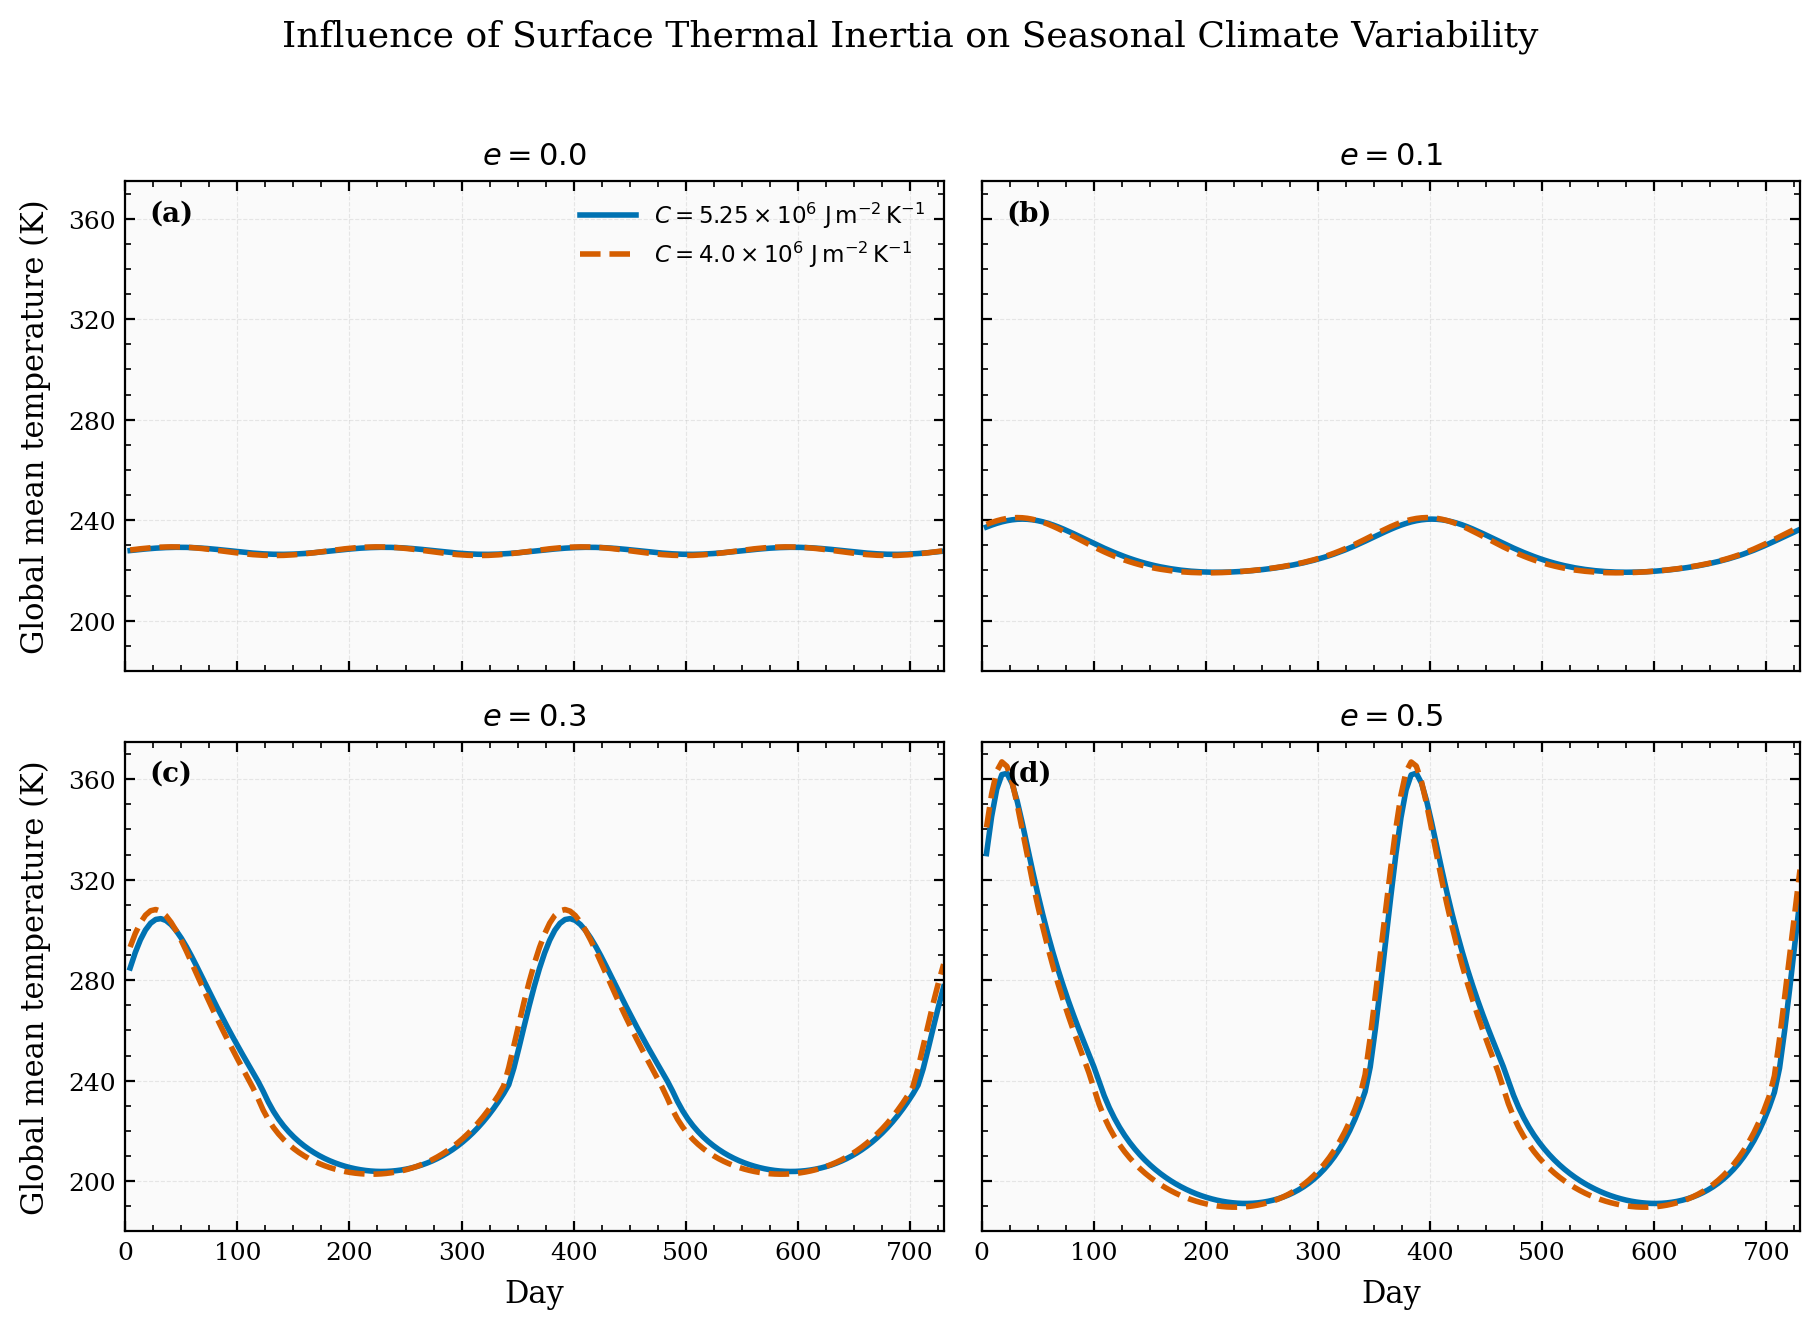

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

# --------------------------------------------------
# Global plotting style
# --------------------------------------------------

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,

    "axes.labelsize": 11,
    "axes.titlesize": 11,

    "xtick.labelsize": 9,
    "ytick.labelsize": 9,

    "axes.linewidth": 0.8,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.top": True,
    "ytick.right": True,

    "xtick.minor.visible": True,
    "ytick.minor.visible": True,

    "axes.facecolor": "#FAFAFA",
    "figure.facecolor": "white",

    "legend.frameon": False
})

# --------------------------------------------------
# Load data
# --------------------------------------------------

df_C525 = pd.read_csv(
    r"C:\Users\MD TALHA ZOBAIR\Downloads\EBM_results\EBM_global_mean_C_525.csv",
    index_col=0
)

df_C4 = pd.read_csv(
    r"C:\Users\MD TALHA ZOBAIR\Downloads\EBM_results2\EBM_global_mean_C_4e6.csv",
    index_col=0
)

eccs = [0.00, 0.10, 0.30, 0.50]

colors = {
    "C_525": "#0072B2",
    "C_4e6": "#D55E00",
}

panel_labels = ["(a)", "(b)", "(c)", "(d)"]

# --------------------------------------------------
# Figure and axes
# --------------------------------------------------

fig, axes = plt.subplots(
    2, 2,
    figsize=(9.2, 6.7),
    dpi=200,
    sharex=True,
    sharey=True
)

axes = axes.flatten()

# --------------------------------------------------
# Plot each eccentricity
# --------------------------------------------------

for i, e in enumerate(eccs):

    ax = axes[i]

    col = f"e={e}"
    t = df_C525.index.values.astype(float)

    # Higher heat capacity
    ax.plot(
        t,
        df_C525[col].values,
        color=colors["C_525"],
        linewidth=2.0,
        linestyle="-",
        label=r"$C = 5.25 \times 10^6\ \mathrm{J\,m^{-2}\,K^{-1}}$"
    )

    # Lower heat capacity
    ax.plot(
        t,
        df_C4[col].values,
        color=colors["C_4e6"],
        linewidth=2.0,
        linestyle="--",
        label=r"$C = 4.0 \times 10^6\ \mathrm{J\,m^{-2}\,K^{-1}}$"
    )

    # ----------------------------------------------
    # Titles and panel labels
    # ----------------------------------------------

    ax.set_title(rf"$e = {e}$", pad=6)

    ax.text(
        0.03, 0.92,
        panel_labels[i],
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold"
    )

    # ----------------------------------------------
    # Ticks and grid
    # ----------------------------------------------

    ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(25))

    ax.yaxis.set_major_locator(ticker.MultipleLocator(40))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(10))

    ax.grid(
        True,
        which="major",
        linestyle="--",
        linewidth=0.4,
        alpha=0.28
    )

    # ----------------------------------------------
    # Axis labels
    # ----------------------------------------------

    if i >= 2:
        ax.set_xlabel("Day", labelpad=5)

    if i % 2 == 0:
        ax.set_ylabel("Global mean temperature (K)", labelpad=6)

    # ----------------------------------------------
    # Axis limits
    # ----------------------------------------------

    ax.set_xlim(0, 730)
    ax.set_ylim(180, 375)

    # ----------------------------------------------
    # Legend only once
    # ----------------------------------------------

    if i == 0:

        ax.legend(
            loc="upper right",
            fontsize=8.3,
            handlelength=2.4,
            borderpad=0.3,
            labelspacing=0.4
        )

# --------------------------------------------------
# Main title
# --------------------------------------------------

fig.suptitle(
    "Influence of Surface Thermal Inertia on Seasonal Climate Variability",
    fontsize=13,
    y=0.985
)

# --------------------------------------------------
# Layout and export
# --------------------------------------------------

plt.tight_layout(rect=[0, 0, 1, 0.965])

plt.savefig(
    r"C:\Users\MD TALHA ZOBAIR\Downloads\EBM_figure4.pdf",
    bbox_inches="tight"
)

plt.savefig(
    r"C:\Users\MD TALHA ZOBAIR\Downloads\EBM_figure4.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()